In [67]:
import numpy as np
import pandas as pd

In [68]:
DATA_ROOT = '../../data/'

In [69]:
meta = pd.read_csv('/home/alexanderb/Zhang_lab/MML_model/data/GEP_Liver_bulk/Hbulk_meta.txt', sep = '\t')
TPM_exp = pd.read_csv('/home/alexanderb/Zhang_lab/MML_model/data/GEP_Liver_bulk/Hbulk_expr.txt', sep = '\t')

In [70]:
meta['Phenotype'].value_counts()

Phenotype
HCC                  724
NAFLD                503
Normal               362
ADJ_HCC              256
Viral Hepatitis      181
HB                   124
ICC                   95
ADJ_HB                93
Cirrhosis             73
ADJ_ICC               60
Dysplastic Nodule     27
ALD                   22
Fibrosis              20
Mixed HCC-ICC         14
Fetal                  8
Fibrolamellar          3
ADJ_Mixed              1
Name: count, dtype: int64

In [ ]:
NAFLD_sample_IDs = list(meta[meta['Phenotype'] == 'Normal']['Run'])

In [6]:
TPM_exp.index = TPM_exp.iloc[:, 0]
TPM_exp = TPM_exp.drop('gene', axis = 1)

In [7]:
GEP_exp = TPM_exp[NAFLD_sample_IDs].T

In [8]:
net = pd.read_csv(f"{DATA_ROOT}/Full data files/network(full).tsv", sep='\t')
#Load target gene expressions
gene_expressions = pd.read_csv((f"{DATA_ROOT}/Full data files/Geneexpression (full).tsv"), sep='\t', header=0)
#load TF expressions
TF_expressions = pd.read_csv((f"{DATA_ROOT}/Full data files/TF(full).tsv"), sep='\t', header=0)

In [9]:
#filter genes to nodes in network
network_tfs = set(net['TF'].unique())      # TFs
network_genes = set(net['Gene'].unique())  # target genes
network_nodes = network_tfs | network_genes

TF_expressions = TF_expressions[[gene for gene in TF_expressions.columns if gene in list(network_nodes)]]
gene_expressions = gene_expressions[[gene for gene in gene_expressions.columns if gene in list(network_nodes)]] 

#define function to subset transcription factors to only those that directly regulate the target gene
def TF_subset(net, target_gene):
    #simpler version as per discussion w/ Cheng
    #returns all the TFs in the network that directly connect to the target gene
    return(list(net['TF'][net['Gene'] == target_gene]))


In [24]:
TF_expressions

,ADNP,ADNP2,AEBP1,AEBP2,AHR,AHRR,AIRE,AKNA,ALX1,ALX3,...,ZSCAN22,ZSCAN23,ZSCAN26,ZSCAN29,ZSCAN31,ZSCAN4,ZSCAN5A,ZSCAN9,ZXDA,ZXDC
0,1.572485,1.387308,1.752547,1.220772,1.632751,0.305561,0.118382,0.917476,0.000000,0.000000,...,0.425673,0.026854,1.390254,1.037898,0.681431,0.522161,0.566212,1.462349,0.668930,1.340183
1,1.371821,0.902596,1.689504,1.166739,1.591647,0.190967,0.000000,0.758821,0.255861,0.080209,...,0.525569,0.633106,1.184793,0.906821,0.583207,0.132401,0.345029,0.698743,0.807861,0.649692
2,1.807409,1.434454,1.921323,1.370208,1.537713,0.995087,0.036967,1.072837,1.342884,0.022257,...,0.775804,0.200174,1.213251,1.193718,0.600653,0.171761,0.546600,1.153740,0.594452,1.129571
3,1.770801,1.427682,1.977897,1.279018,1.461763,1.081572,0.036349,1.100877,1.323910,0.117274,...,0.767559,0.163194,1.155250,1.167529,0.526560,0.188859,0.559269,1.142929,0.652413,1.164511
4,1.790020,1.435589,1.972414,1.336620,1.501878,1.087614,0.081983,1.094249,1.356873,0.027587,...,0.752056,0.185510,1.183875,1.160435,0.579474,0.197615,0.544898,1.126543,0.561892,1.139375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15930,2.128353,1.545015,0.082729,1.637646,1.477073,0.958705,0.000000,0.882644,0.000000,0.000000,...,0.587592,0.304653,1.126349,1.465046,0.996619,0.073912,0.488005,1.105604,0.776040,1.324217
15931,2.129606,1.511823,0.084903,1.650216,1.520787,0.948769,0.103009,0.866975,0.000000,0.072271,...,0.584821,0.331277,1.200898,1.461839,1.010232,0.064113,0.499476,1.142201,0.728295,1.356000
15932,2.109642,1.485288,0.015855,1.612011,1.460114,0.922514,0.063725,0.828420,0.000000,0.000000,...,0.586529,0.381567,1.073323,1.460320,1.038161,0.034301,0.483772,1.156908,0.698932,1.281206
15933,1.787014,1.322174,0.016743,1.608921,1.389450,0.586336,0.051268,0.862423,0.000000,0.078369,...,0.284116,0.497276,1.158055,1.450912,0.723975,0.000000,0.310714,1.375681,0.710359,1.215786


In [25]:
#All original dataset TFs are in the GEP dataset
GEP_TFs = GEP_exp[list(TF_expressions.columns)]

In [36]:
GEP_TFs

gene,ADNP,ADNP2,AEBP1,AEBP2,AHR,AHRR,AIRE,AKNA,ALX1,ALX3,...,ZSCAN22,ZSCAN23,ZSCAN26,ZSCAN29,ZSCAN31,ZSCAN4,ZSCAN5A,ZSCAN9,ZXDA,ZXDC
SRR8601526,2.908849,0.559137,6.598684,0.617069,1.108232,0.011004,0.000000,0.422395,0.0,0.000000,...,0.219020,0.000000,1.757146,0.764127,0.374968,0.000000,0.252231,0.456070,0.082166,1.194325
SRR8601527,2.662022,0.713417,3.061144,0.576992,2.060610,0.085892,0.000000,0.692074,0.0,0.000000,...,0.463016,0.000000,0.730753,0.472191,0.249449,0.000000,0.123052,0.311494,0.040085,0.862779
SRR8601528,2.842297,0.646636,9.964169,0.415963,1.465917,0.021578,0.000000,0.461045,0.0,0.000000,...,0.662145,0.000000,1.214493,0.649331,0.384368,0.000000,0.247313,0.402460,0.181268,1.880417
SRR8601529,3.644769,0.876985,3.300243,0.786377,1.527245,0.040185,0.000000,0.596652,0.0,0.000000,...,0.399924,0.000000,1.919838,0.965064,0.715801,0.000000,0.230284,0.562120,0.187540,1.604148
SRR8601530,5.231817,1.288219,9.902494,0.901560,3.207785,0.024115,0.000000,1.100363,0.0,0.000000,...,0.359996,0.000000,3.030202,1.325747,0.803086,0.041165,0.253357,0.699652,0.247597,2.529343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR2618809,32.946940,16.457260,39.687680,13.455960,36.669010,0.159084,0.000000,8.572345,0.0,0.000000,...,3.694149,0.892923,15.575180,12.593720,4.435342,0.108621,2.491812,6.395685,5.523670,22.512950
ERR2618810,18.445690,8.172128,39.223680,3.169568,14.567560,0.298679,0.000000,8.076110,0.0,0.000000,...,3.178883,0.349262,5.994415,8.209949,2.158938,0.000000,0.855799,4.435895,3.345375,11.637200
ERR2618811,23.671490,9.891046,14.278400,8.624466,27.384380,0.130889,0.000000,5.422504,0.0,0.000000,...,2.127598,0.734668,10.279210,8.483269,3.527614,0.089370,1.375122,4.556924,3.274136,11.856860
ERR2618812,25.463000,11.166070,12.613080,10.159050,23.252870,0.179292,0.029427,8.453627,0.0,0.073224,...,4.282371,0.587038,8.964586,10.479120,2.582694,0.061210,1.455546,5.424673,4.217167,18.000450


In [34]:
pd.Series(GEP_TFs.columns == TF_expressions.columns).value_counts()

True    1197
Name: count, dtype: int64

In [11]:
#15643 of the 16,1000 target genes in the dataset
GEP_target_genes = GEP_exp[[gene for gene in gene_expressions.columns if gene in GEP_exp.columns]]

In [35]:
GEP_target_genes.to_csv(f'{DATA_ROOT}/GEP_Liver_bulk/GEP_gene_expressions.csv')
GEP_TFs.to_csv(f'{DATA_ROOT}/GEP_Liver_bulk/GEP_TF_expressions.csv')

In [13]:
TF_expression_subset = GEP_TFs[TF_subset(net, 'A2M')]

In [17]:
np.asarray(TF_expression_subset).T

array([[  1.766113,   1.862929,   3.556958, ...,  14.08086 ,   8.399616,
         12.19622 ],
       [  4.132309,   5.350953,   4.578181, ...,  77.43654 ,  65.53396 ,
         79.59845 ],
       [ 21.38092 ,  27.26748 ,  29.85786 , ...,  39.66424 ,  71.29343 ,
        179.8094  ],
       ...,
       [  0.      ,   0.      ,   0.      , ...,   1.17471 ,   0.      ,
          0.      ],
       [  2.052426,   1.949868,   2.330156, ...,  16.89664 ,  18.72287 ,
         15.71125 ],
       [  1.677819,   1.443198,   1.818274, ...,  10.34638 ,  10.46751 ,
          5.206885]])

In [22]:
import torch

In [ ]:
torch.tensor(np.asarray(GEP_target_genes['A2M']), dtype = torch.float32) 

tensor([ 132.3418,   38.5960,   88.1469,   81.3885,  410.6742,  449.8441,
         151.1174,  498.5701,  216.1308,   76.6909,   29.7569,   96.8795,
         376.9228,  306.0165,  295.3460,  354.7825,  382.6358,  838.4107,
         512.8471,  170.5169,  169.1047,  437.7477,  623.4541,   80.6957,
         355.1428,  716.1947,  353.9235,  529.0793,  326.5992,  855.7998,
         244.4316,  799.6022,  758.7270, 1196.3571,  595.3123, 1028.9189,
         380.6177,  422.4614,  161.6906, 1323.6479,  311.4376,  547.6257,
         454.4675,  137.1845,  500.4105,  912.7426,  415.8236,  456.0040,
        1311.4640,  134.5424,  635.4503, 1087.0330,  529.1619,  773.2839,
         267.6206,  698.7226,  576.2536, 1494.4139, 1485.0540,  262.0778,
         468.2784,  153.9480,  321.7377, 1422.7841,  610.5760,  537.9297,
         693.5990,  333.9832, 1210.5699,  172.4093, 1052.2889,  138.3306,
         967.6009,  827.0886, 1290.0310,  140.2077,  360.3676,  329.4829,
         505.4260,  519.5598,  836.127

# Results

In [1]:
import pandas as pd
import numpy as np

In [28]:
NAFLD_acc = pd.read_csv('../../data/GEP_Liver_bulk/GEP_NAFLD_gene_expressions.csv', index_col=0)
NAFLD_pred = pd.read_csv(f'../data/GEP_results/GEP_NAFLD_results.csv', index_col=0)
NAFLD_pred = NAFLD_pred.dropna(axis = 'columns')

#filter actual gene expressions to just those genes could construct a model for
NAFLD_acc = NAFLD_acc[NAFLD_pred.columns]

#match named indexes
NAFLD_pred.index = NAFLD_acc.index

In [29]:
Normal_acc = pd.read_csv('../../data/GEP_Liver_bulk/GEP_Normal_gene_expressions.csv', index_col=0)
Normal_pred = pd.read_csv(f'../data/GEP_results/GEP_Normal_results.csv', index_col=0)
Normal_pred = Normal_pred.dropna(axis = 'columns')

#filter actual gene expressions to just those genes could construct a model for
Normal_acc = Normal_acc[Normal_pred.columns]

Normal_pred.index = Normal_acc.index

In [24]:
#re-use function from model pearsons scoring - easier to include like this than importing into notebook
import scipy
from sklearn.metrics import mean_squared_error
def get_correlations_df(df1, df2, dataset_label, rowise = True):
    '''
    Uses get_correlations to calculate the row or columnwise perasons correlations between two dataframes with the same dimensions
    
    Returns the result as a df suitable for later concatenating and use with seaborn violin plots where the columns are ['value', 'dataset']
    The resulting dataframe has dimensions (n, 2) where n is the number of rows in df1 
    '''

    #initialise df
    if rowise == False:
        results_df = pd.DataFrame(columns = ['pearsons', 'spearmans','MSE', 'dataset'], index = df1.columns)
    else:
        results_df = pd.DataFrame(columns = ['pearsons', 'spearmans','MSE', 'dataset'], index = df1.index)
    #add pearsons correlation between df1, df2 to the pearsons column

    if rowise == False:
        df1 = df1.T
        df2 = df2.T

    for i in results_df.index:
        results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(df1.loc[i, :], df2.loc[i, :]).statistic
        results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.loc[i, :], df2.loc[i, :]).statistic
        results_df.loc[i, 'MSE'] = mean_squared_error(df1.loc[i, :], df2.loc[i, :])
        results_df.loc[i, "dataset"] = dataset_label

    return(results_df)

In [30]:
#calculate pearsons, spearmans and MSE
NAFLD_genewise_correlations = get_correlations_df(NAFLD_pred, NAFLD_acc, dataset_label='GEP_NAFLD', rowise=False)
NAFLD_samplewise_correlations = get_correlations_df(NAFLD_pred, NAFLD_acc, dataset_label='GEP_NAFLD', rowise=True)

/tmp/ipykernel_31052/2318797478.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:24: ConstantInputWarning: An input array is const

In [31]:
#calculate pearsons, spearmans and MSE
Normal_genewise_correlations = get_correlations_df(Normal_pred, Normal_acc, dataset_label='GEP_Normal', rowise=False)
Normal_samplewise_correlations = get_correlations_df(Normal_pred, Normal_acc, dataset_label='GEP_Normal', rowise=True)

/tmp/ipykernel_31052/2318797478.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, "pearsons"] = scipy.stats.pearsonr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  results_df.loc[i, 'spearmans'] = scipy.stats.spearmanr(df1.loc[i, :], df2.loc[i, :]).statistic
/tmp/ipykernel_31052/2318797478.py:24: ConstantInputWarning: An input array is const

In [32]:
Normal_genewise_correlations

,pearsons,spearmans,MSE,dataset
A2M,-0.311537,-0.389837,942944.112762,GEP_Normal
A2ML1,-0.067878,0.080112,1.044913,GEP_Normal
A3GALT2,-0.105922,-0.033932,0.130831,GEP_Normal
A4GALT,0.293827,0.359462,6.474095,GEP_Normal
AAAS,0.125896,0.05978,177.554232,GEP_Normal
...,...,...,...,...
PRKAR1A,0.707941,0.705719,1971.751591,GEP_Normal
PRKAR2A,0.251162,0.271595,222.452542,GEP_Normal
PRKCA,0.266615,0.261258,83.749903,GEP_Normal
PRKCB,-0.189382,-0.023885,4.734716,GEP_Normal


In [33]:
NAFLD_genewise_correlations

,pearsons,spearmans,MSE,dataset
A2M,-0.241595,-0.289518,1047587.149766,GEP_NAFLD
A2ML1,0.185761,0.121216,0.787411,GEP_NAFLD
A3GALT2,0.047769,-0.025997,0.088606,GEP_NAFLD
A4GALT,0.424608,0.406013,0.139779,GEP_NAFLD
AAAS,0.06575,0.016377,128.538061,GEP_NAFLD
...,...,...,...,...
GRK2,0.869734,0.831263,98.0081,GEP_NAFLD
GRK3,0.614916,0.748509,6.225288,GEP_NAFLD
GRK5,0.58104,0.539756,10.722664,GEP_NAFLD
GRK6,0.396717,0.348674,15.472548,GEP_NAFLD


In [8]:
def create_pearsons_violin(results_df, y_col, title, file_title, figure_root = './figures', **kwargs):
    '''
    Taking a results df with two columns ['pearsons', 'dataset'] 
    Plots the pearsons values by dataset of origin as violin plots and saves figure with specified file_title at figure_root

    Parameters
    ---------------
    results_df : pandas dataframe
        dataframe containg the results to plot. Must contain a categorical column called dataset to serve as x axis categories
    y_col : string
        name of column in results df with statistic to make violin plot for 
    title : string
        title to display on plot
    file_title : string
        filename of saved figure
    figure_root : string
        path to directory in which to save the figure

    Returns
    --------------
    None
        Saves figure to desired location
    '''

    #store all plot formating arguments in dictionary - kwargs can then override
    plot_defaults = {'ylim':(-1, 1),
                     'palette':'viridis'}

    plot_kwargs = {**plot_defaults, **kwargs}

    #violin_plot_arguments = list(inspect.signature(sns.violinplot).parameters.keys())

    savepath = f'{figure_root}/{file_title}'

    fig, ax = plt.subplots()
    
    ax = sns.violinplot(data = results_df, x = 'dataset', y= y_col, hue = 'dataset', palette=plot_kwargs['palette'])

    if y_col == 'pearsons':
        ax.set_ylabel('Pearsons R', fontsize = 15)
    elif y_col == 'spearmans':
        ax.set_ylabel('Spearmans Rank', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
   
    plt.ylim(plot_kwargs['ylim'])
    fig.suptitle(title, fontsize = 20)
    plt.savefig(savepath, dpi = 300, bbox_inches = 'tight')

In [35]:
Normal_genewise_correlations

,pearsons,spearmans,MSE,dataset
A2M,-0.311537,-0.389837,942944.112762,GEP_Normal
A2ML1,-0.067878,0.080112,1.044913,GEP_Normal
A3GALT2,-0.105922,-0.033932,0.130831,GEP_Normal
A4GALT,0.293827,0.359462,6.474095,GEP_Normal
AAAS,0.125896,0.05978,177.554232,GEP_Normal
...,...,...,...,...
PRKAR1A,0.707941,0.705719,1971.751591,GEP_Normal
PRKAR2A,0.251162,0.271595,222.452542,GEP_Normal
PRKCA,0.266615,0.261258,83.749903,GEP_Normal
PRKCB,-0.189382,-0.023885,4.734716,GEP_Normal


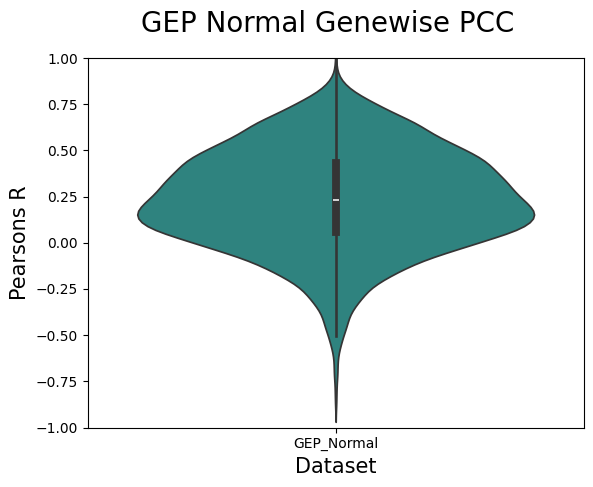

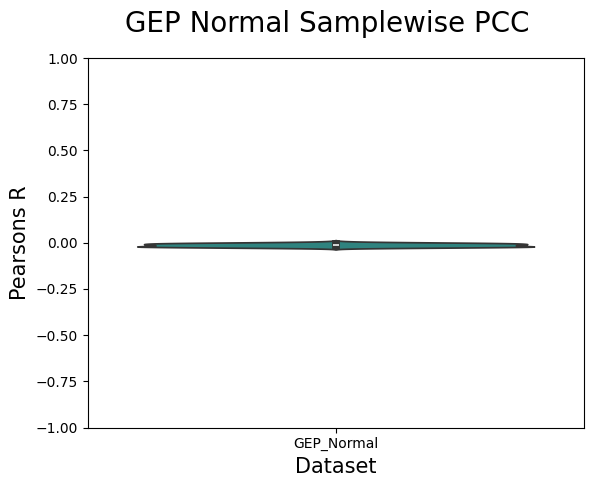

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

create_pearsons_violin(Normal_genewise_correlations, y_col='pearsons', title = 'GEP Normal Genewise PCC', file_title='GEP_Normal_genewise_pcc', figure_root='../figures/GEP_NAFLD')
create_pearsons_violin(Normal_samplewise_correlations, y_col='pearsons', title = 'GEP Normal Samplewise PCC', file_title='GEP_Normal_samplewise_pcc', figure_root='../figures/GEP_NAFLD')

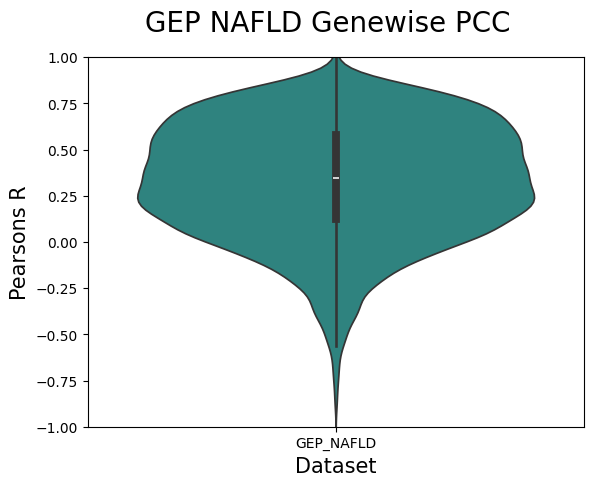

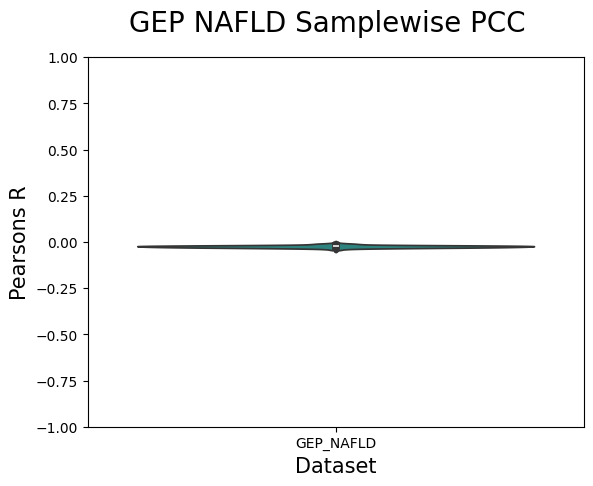

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

create_pearsons_violin(NAFLD_genewise_correlations, y_col='pearsons', title = 'GEP NAFLD Genewise PCC', file_title='GEP_NAFLD_genewise_pcc', figure_root='../figures/GEP_NAFLD')
create_pearsons_violin(NAFLD_samplewise_correlations, y_col='pearsons', title = 'GEP NAFLD Samplewise PCC', file_title='GEP_NAFLD_samplewise_pcc', figure_root='../figures/GEP_NAFLD')